1. Importing the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

2. Data Loading and handlingunderstanding

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
pd.set_option("display.max_columns", None)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#dropping customerID column as this is not required for modelling
df = df.drop(columns=["customerID"])

In [9]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
print(df["gender"].unique())

['Female' 'Male']


In [12]:
print(df["SeniorCitizen"].unique())

[0 1]


In [13]:
#printing the unique values in all the columns

numerical_features_list = ["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
  if col not in numerical_features_list:
    print(col,df[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [14]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
#df["TotalCharges"]=df["TotalCharges"].astype(float)

In [16]:
df[df["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [17]:
len(df[df["TotalCharges"]==" "])

11

In [18]:
df["TotalCharges"]= df["TotalCharges"].replace({" ":"0.0"})

In [19]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [21]:
#checking the class distribution of target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Insights:
1. Customer ID removed as it is not required for modelling
2. No Missing values in the dataset
3. Missing values in the TotalCharges column were replaced with 0
4. class imbalance identified in the target

3. Explorartory data analysis(EDA)

In [22]:
df.shape

(7043, 20)

In [23]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [24]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


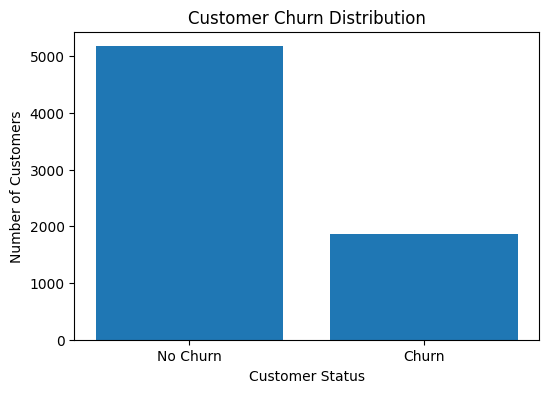

In [85]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["No Churn", "Churn"], churn_counts.values)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

**Numerical features - analysis**

Understand the distribution of the numerical features

In [26]:
def plot_histogram(df, column_name):

    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    # Calculate the mean and median values for the column
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    # Add vertical lines for mean and median
    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="--", label="Median")

    plt.legend()
    plt.show()

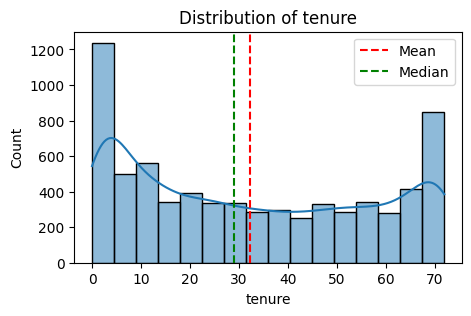

In [27]:
plot_histogram(df, "tenure")

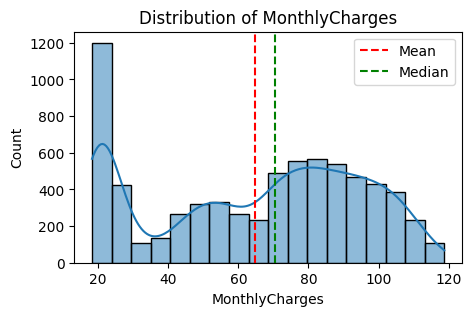

In [28]:
plot_histogram(df, "MonthlyCharges")

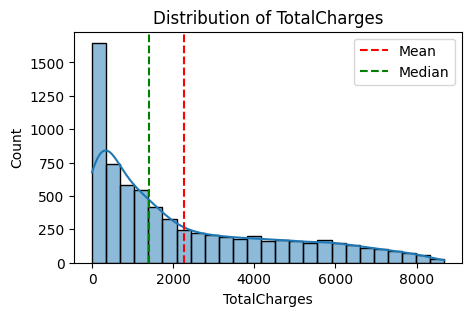

In [29]:
plot_histogram(df, "TotalCharges")

**Box plot for numerical features**

In [30]:
def plot_boxplot(df, column_name):

    plt.figure(figsize=(5, 3))
    sns.boxplot(df[column_name])
    plt.title(f"Distribution of {column_name}")
    plt.ylabel(column_name)

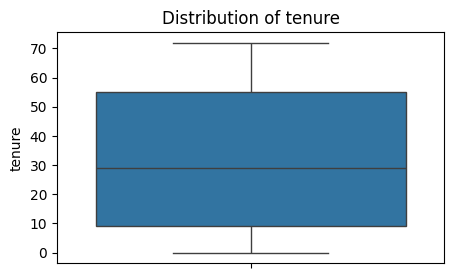

In [31]:
plot_boxplot(df, "tenure")

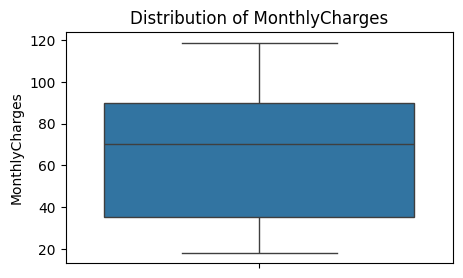

In [32]:
plot_boxplot(df, "MonthlyCharges")

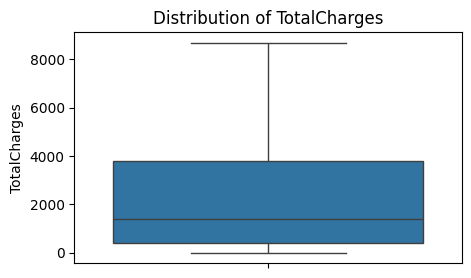

In [33]:
plot_boxplot(df, "TotalCharges")

**Correlation Heatmap for numerical columns**

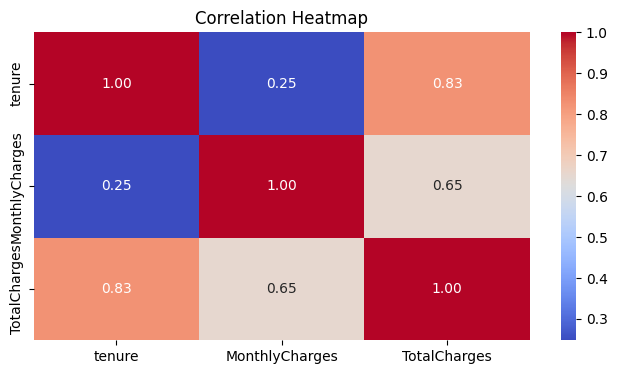

In [34]:
# Correlation matrix + heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

**Categorical Features - Analysis**

In [35]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Countplot for categorical columns

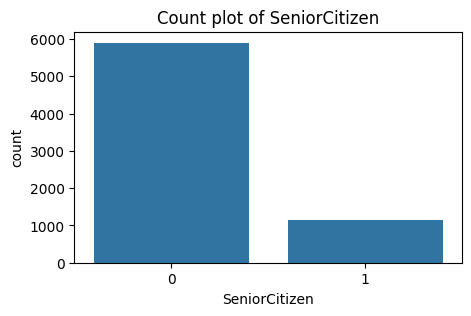

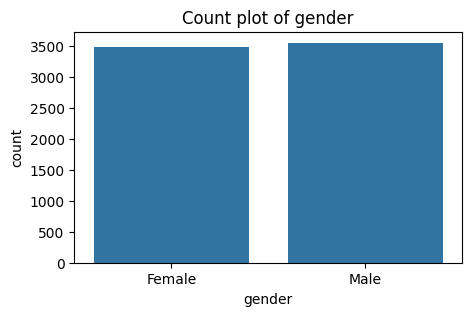

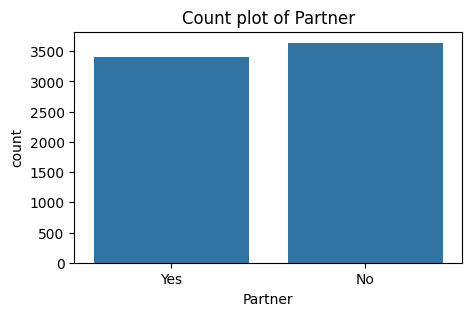

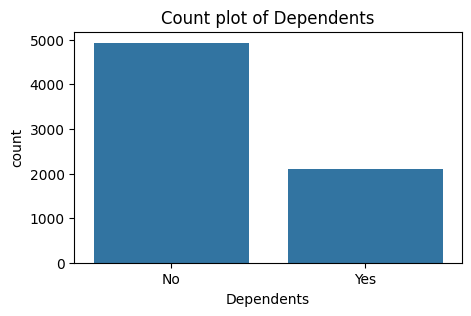

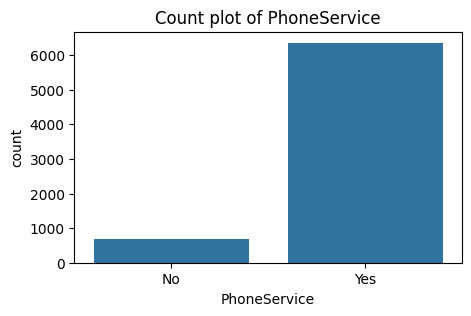

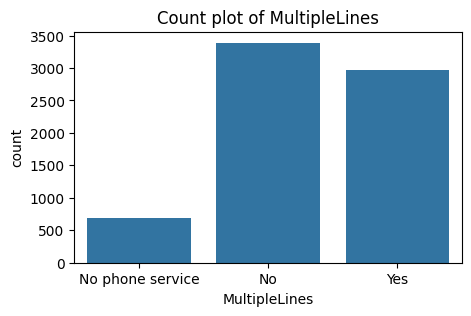

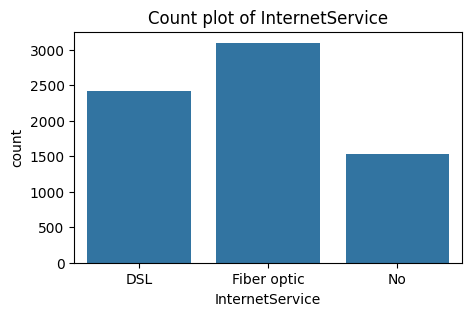

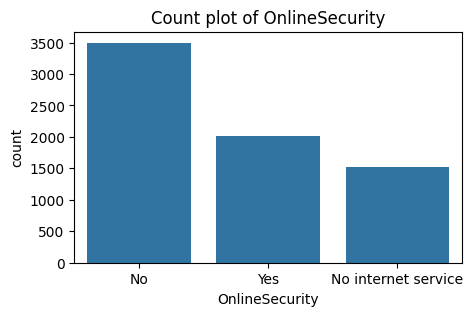

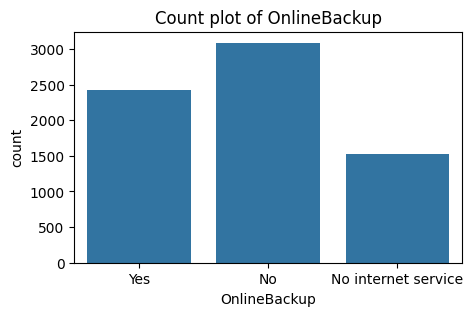

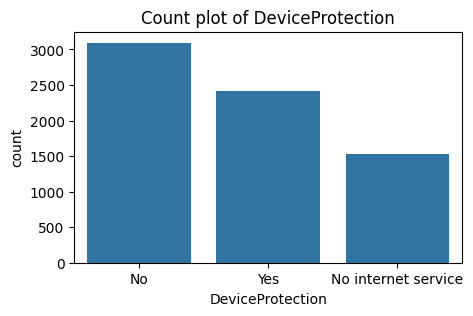

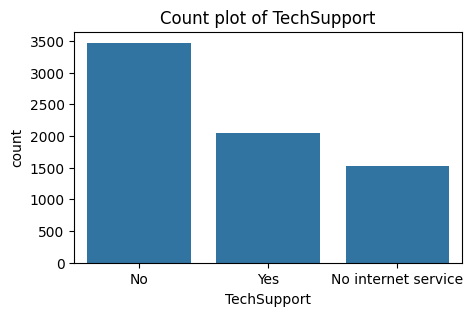

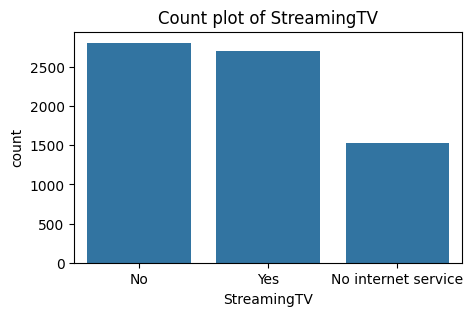

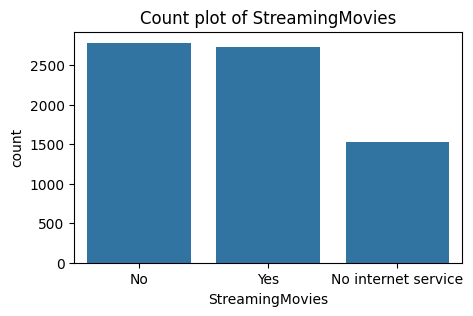

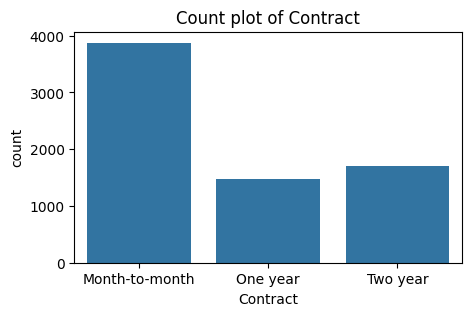

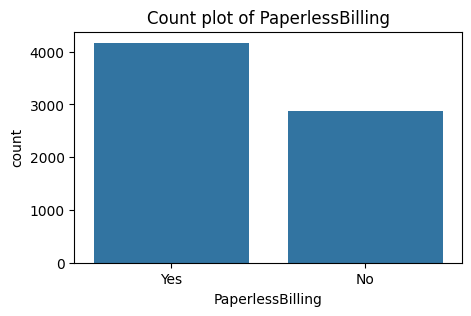

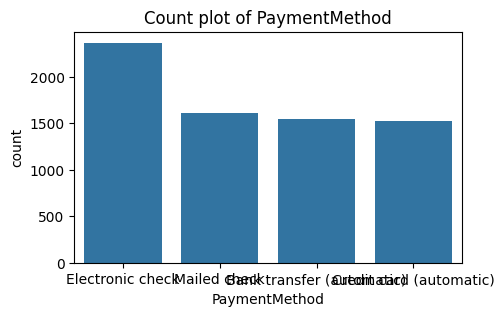

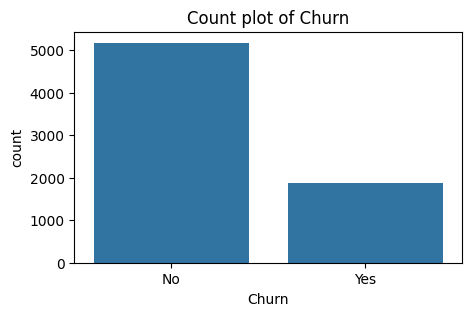

In [37]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count plot of {col}")
    plt.show()

**4.Data Preprocessing**

In [38]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


Label encoding of Target Column

In [39]:
df["Churn"]=df["Churn"].replace({"Yes":1, "No":0})

/tmp/ipykernel_2378/2716532976.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"]=df["Churn"].replace({"Yes":1, "No":0})


In [40]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [41]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


**Label Encoding of categorical features**

In [42]:
#identifying columns with object datatype
object_columns=df.select_dtypes(include="object").columns

In [43]:
print(object_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [44]:
#initialize a dictionary to save the encoders
encoders={}
#apply label encoding and store the encoders
for column in object_columns:
  label_encoder=LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

#save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

In [45]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [46]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Training and test data split**

In [47]:
#splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [48]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [49]:
#split training and test data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [50]:
print(y_train.shape)

(5634,)


In [51]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


**SMOTE(Synthetic Minority Oversampling Technique)**

In [52]:
smote = SMOTE(random_state=42)

In [53]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [54]:
print(y_train_smote.shape)

(8276,)


In [55]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


**5. Model Training**

Training with default hyperparameters

In [56]:
#dictionary of models
models ={
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}


In [57]:
#dictionary to store the cross validation results
cv_scores ={}

#perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*60)


Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.83
------------------------------------------------------------


In [58]:
cv_scores

{'Decision Tree': array([0.68297101, 0.71299094, 0.82175227, 0.83564955, 0.83564955]),
 'Random Forest': array([0.72524155, 0.77824773, 0.90513595, 0.89425982, 0.90090634]),
 'XGBoost': array([0.71135266, 0.74984894, 0.90271903, 0.89607251, 0.89667674])}

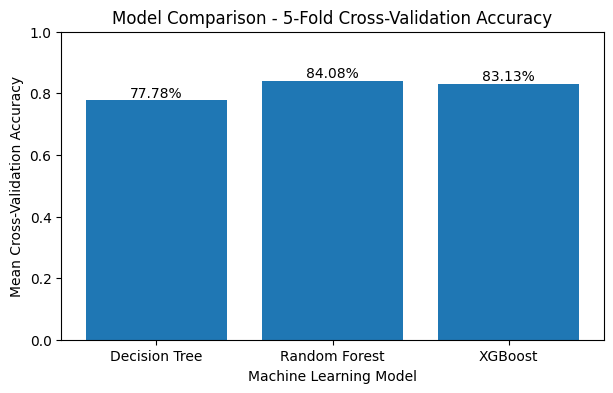

In [59]:
# Model Comparison - Cross Validation Accuracy

model_names = list(cv_scores.keys())
cv_accuracies = [np.mean(cv_scores[model]) for model in model_names]

plt.figure(figsize=(7, 4))

plt.bar(model_names, cv_accuracies)

plt.ylim(0, 1)
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Model Comparison - 5-Fold Cross-Validation Accuracy")

for i, score in enumerate(cv_accuracies):
    plt.text(i, score + 0.01, f"{score:.2%}", ha="center")

plt.show()

Random Forest gives the highest accuracy compared to other models with default parameters

In [60]:
rfc = RandomForestClassifier(random_state=42)

In [61]:
rfc.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [62]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


**6. Model Evaluation**

In [63]:
# evaluate on test data
y_test_pred = rfc.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.7785663591199432
Confusion Matrix:
 [[878 158]
 [154 219]]
Classification report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



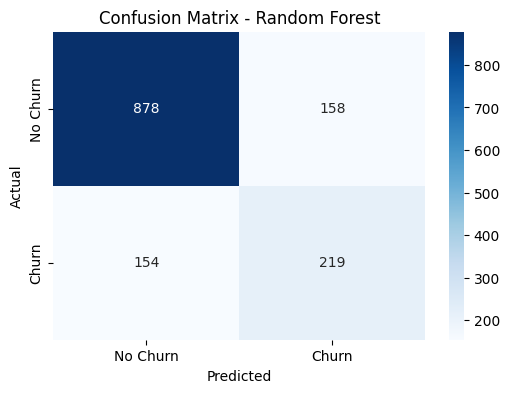

In [64]:
# Confusion Matrix Heatmap

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [70]:
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline

In [71]:
# Stratified 5-Fold Cross-Validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [72]:
# Random Forest with SMOTE inside the cross-validation pipeline

rfc_cv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [73]:
# Corrected Stratified Cross-Validation

rfc_cv_scores = cross_val_score(
    rfc_cv_pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy"
)

print("Random Forest - Stratified 5-Fold Cross-Validation")
print("Fold accuracies:", rfc_cv_scores)
print(f"Mean accuracy: {rfc_cv_scores.mean():.4f}")
print(f"Standard deviation: {rfc_cv_scores.std():.4f}")

Random Forest - Stratified 5-Fold Cross-Validation
Fold accuracies: [0.76397516 0.78438332 0.76486247 0.77196096 0.79040853]
Mean accuracy: 0.7751
Standard deviation: 0.0106


In [74]:
# Corrected Stratified 5-Fold Cross-Validation for all models
# SMOTE is applied separately within each training fold

corrected_cv_scores = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=skf,
        scoring="accuracy"
    )

    corrected_cv_scores[model_name] = scores

    print(f"{model_name} - Corrected Stratified 5-Fold CV")
    print(f"Fold accuracies: {scores}")
    print(f"Mean accuracy: {scores.mean():.4f}")
    print(f"Standard deviation: {scores.std():.4f}")
    print("-" * 60)

Decision Tree - Corrected Stratified 5-Fold CV
Fold accuracies: [0.72138421 0.72315883 0.70984916 0.70275067 0.71136767]
Mean accuracy: 0.7137
Standard deviation: 0.0076
------------------------------------------------------------
Random Forest - Corrected Stratified 5-Fold CV
Fold accuracies: [0.76397516 0.78438332 0.76486247 0.77196096 0.79040853]
Mean accuracy: 0.7751
Standard deviation: 0.0106
------------------------------------------------------------
XGBoost - Corrected Stratified 5-Fold CV
Fold accuracies: [0.76131322 0.7755102  0.76663709 0.75244011 0.77619893]
Mean accuracy: 0.7664
Standard deviation: 0.0089
------------------------------------------------------------


In [75]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest with SMOTE inside the pipeline
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Smaller hyperparameter search space
param_distributions = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="accuracy",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(f"{random_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': None}

Best Cross-Validation Accuracy:
0.7776


In [76]:
# Evaluate the tuned Random Forest on the unseen test data

best_rf_model = random_search.best_estimator_

# Predictions
y_tuned_pred = best_rf_model.predict(X_test)

# Prediction probabilities
y_tuned_prob = best_rf_model.predict_proba(X_test)[:, 1]

# Accuracy
tuned_accuracy = accuracy_score(y_test, y_tuned_pred)

print(f"Tuned Random Forest Test Accuracy: {tuned_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_tuned_pred,
        target_names=["No Churn", "Churn"]
    )
)

# Confusion matrix
tuned_cm = confusion_matrix(y_test, y_tuned_pred)

print("\nConfusion Matrix:")
print(tuned_cm)

# ROC-AUC
tuned_roc_auc = roc_auc_score(y_test, y_tuned_prob)

print(f"\nTuned Random Forest ROC-AUC: {tuned_roc_auc:.4f}")

Tuned Random Forest Test Accuracy: 0.7750

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1036
       Churn       0.57      0.62      0.60       373

    accuracy                           0.78      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Confusion Matrix:
[[859 177]
 [140 233]]

Tuned Random Forest ROC-AUC: 0.8330


In [77]:
from sklearn.metrics import roc_curve

# Calculate ROC curve for the tuned Random Forest
fpr, tpr, thresholds = roc_curve(y_test, y_tuned_prob)

print("ROC-AUC:", tuned_roc_auc)

ROC-AUC: 0.8329662964381462


In [78]:
print("FPR =", fpr.tolist())
print("TPR =", tpr.tolist())

FPR = [0.0, 0.0, 0.0, 0.0019305019305019305, 0.0019305019305019305, 0.0028957528957528956, 0.0028957528957528956, 0.003861003861003861, 0.003861003861003861, 0.004826254826254826, 0.004826254826254826, 0.005791505791505791, 0.005791505791505791, 0.006756756756756757, 0.006756756756756757, 0.007722007722007722, 0.007722007722007722, 0.008687258687258687, 0.008687258687258687, 0.009652509652509652, 0.009652509652509652, 0.013513513513513514, 0.013513513513513514, 0.016409266409266408, 0.016409266409266408, 0.017374517374517374, 0.017374517374517374, 0.01833976833976834, 0.01833976833976834, 0.019305019305019305, 0.019305019305019305, 0.02027027027027027, 0.02027027027027027, 0.0222007722007722, 0.0222007722007722, 0.02413127413127413, 0.02413127413127413, 0.026061776061776062, 0.026061776061776062, 0.02702702702702703, 0.02702702702702703, 0.027992277992277992, 0.027992277992277992, 0.02895752895752896, 0.02895752895752896, 0.029922779922779922, 0.029922779922779922, 0.03088803088803089,

In [79]:
# Save actual ROC curve data for the Streamlit frontend

roc_data = {
    "fpr": fpr,
    "tpr": tpr,
    "roc_auc": tuned_roc_auc
}

with open("roc_data.pkl", "wb") as f:
    pickle.dump(roc_data, f)

print("ROC curve data saved successfully.")

ROC curve data saved successfully.


In [80]:
# Save the final tuned Random Forest model

import pickle

final_model = best_rf_model

with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Final model saved successfully.")

Final model saved successfully.


In [81]:
# save the final tuned model as a pickle file
with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("Final tuned model saved successfully.")

Final tuned model saved successfully.


**7. Load the saved model and build the predictive system**

In [82]:
# Load the saved final tuned model

with open("customer_churn_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


# Input data for an unseen customer
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85,
}

input_data_df = pd.DataFrame([input_data])


# Load the saved label encoders
with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)


# Encode categorical features using the saved label encoders
for column, encoder in encoders.items():
    input_data_df[column] = encoder.transform(input_data_df[column])


# Make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)[:, 1]


# Print the prediction
print(prediction)

print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Churn Probability: {pred_prob[0]:.2%}")

[0]
Prediction: No Churn
Churn Probability: 44.75%


In [83]:
input_data_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85


In [84]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}